# Libraries

In [1]:
from qiskit.primitives import Sampler  # Should work
from qiskit_machine_learning.kernels import FidelityQuantumKernel  # Should work
print("All imports successful!")

All imports successful!


In [2]:
from pathlib import Path
# import tensorflow as tf
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
import requests
import seaborn as sns

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time

#Importing Libraries
from sklearn.svm import SVC
from sklearn.metrics.pairwise import rbf_kernel

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression

import os
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

#from qiskit.utils import algorithm_globals
from qiskit.circuit.library import PauliFeatureMap, ZZFeatureMap
# from qiskit_algorithms.state_fidelities import ComputeUncompute
# from qiskit_machine_learning.kernels import FidelityQuantumKernel

# from qiskit_ibm_runtime import QiskitRuntimeService
# from qiskit_machine_learning.algorithms.classifiers import QSVC
# from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_ibm_runtime import QiskitRuntimeService#, SamplerV2 as Sampler

from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit import transpile
from sklearn.svm import SVC
from qiskit.circuit import QuantumCircuit
from qiskit import transpile
from qiskit.circuit.library import RealAmplitudes
# from qiskit_algorithms.optimizers import COBYLA
# from qiskit.primitives import BaseSampler
#from qiskit.primitives import Sampler
#from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, SamplerV2

np.random.seed(42)
#algorithm_globals.random_seed = 123

/Users/sthefaniepasso/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Dataset

[ClaMp](https://www.kaggle.com/code/ssmohanty/dimensionality-reduction-techniques)

In [3]:
# Make with this dataset a pearson corelation hank and select just the 10 most relevant features
# plot this features in a correlation matrix
# create a vector ranck_feature with all 10 features from the most to least relevant

Categorical columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
Numeric columns (0): []...

PEARSON CORRELATION RANKING (Top 20)
 1. count                    :  0.9146 (|r| = 0.9146)
 2. srv_count                :  0.7831 (|r| = 0.7831)
 3. dst_host_srv_serror_rate :  0.4452 (|r| = 0.4452)
 4. dst_host_serror_rat

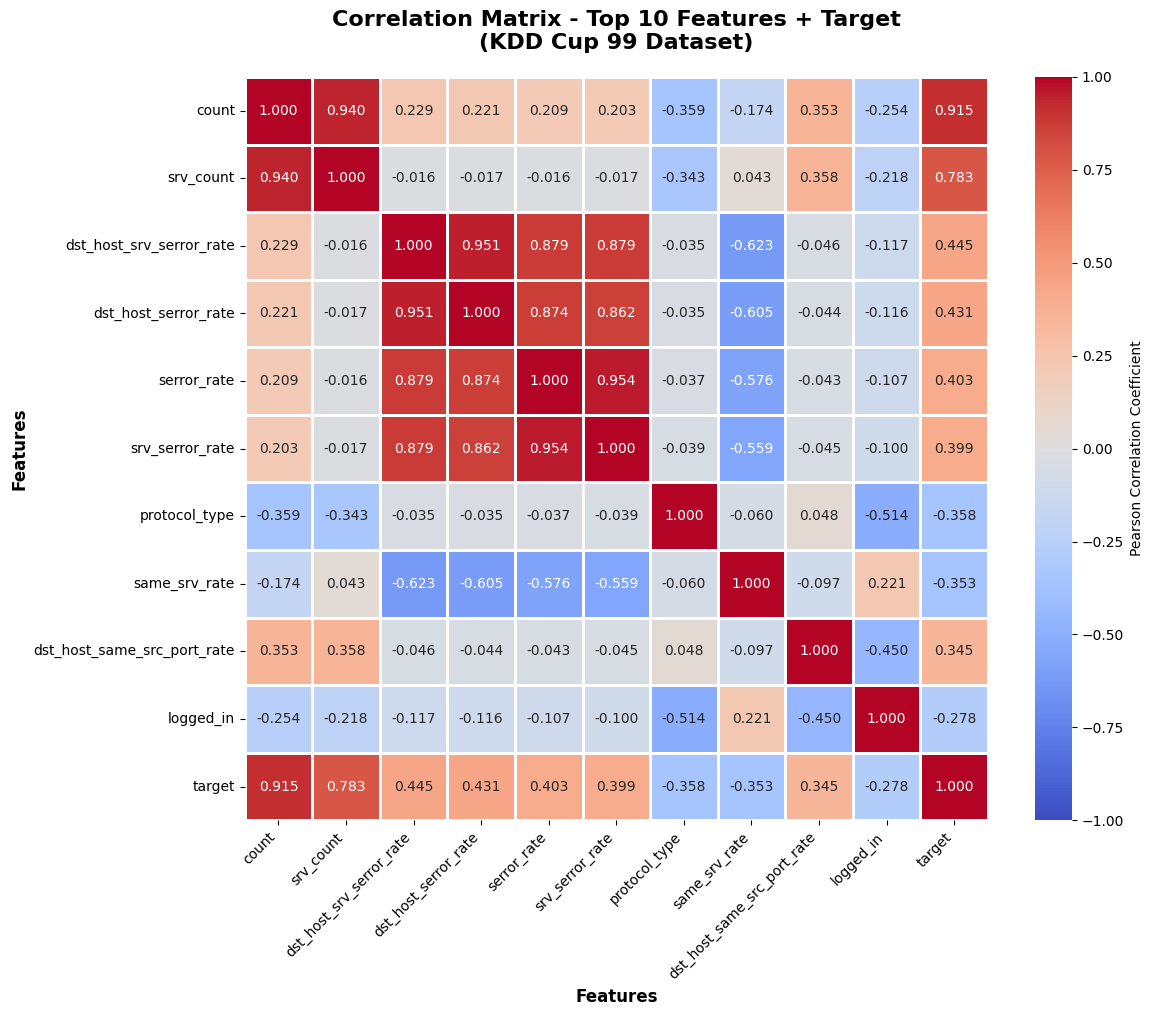

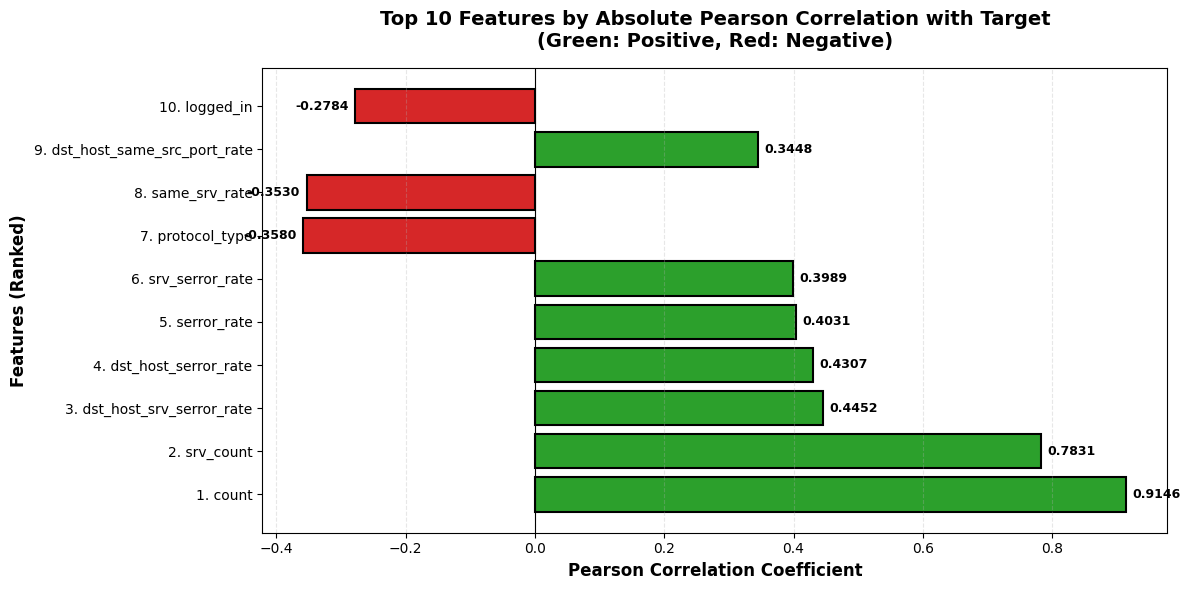

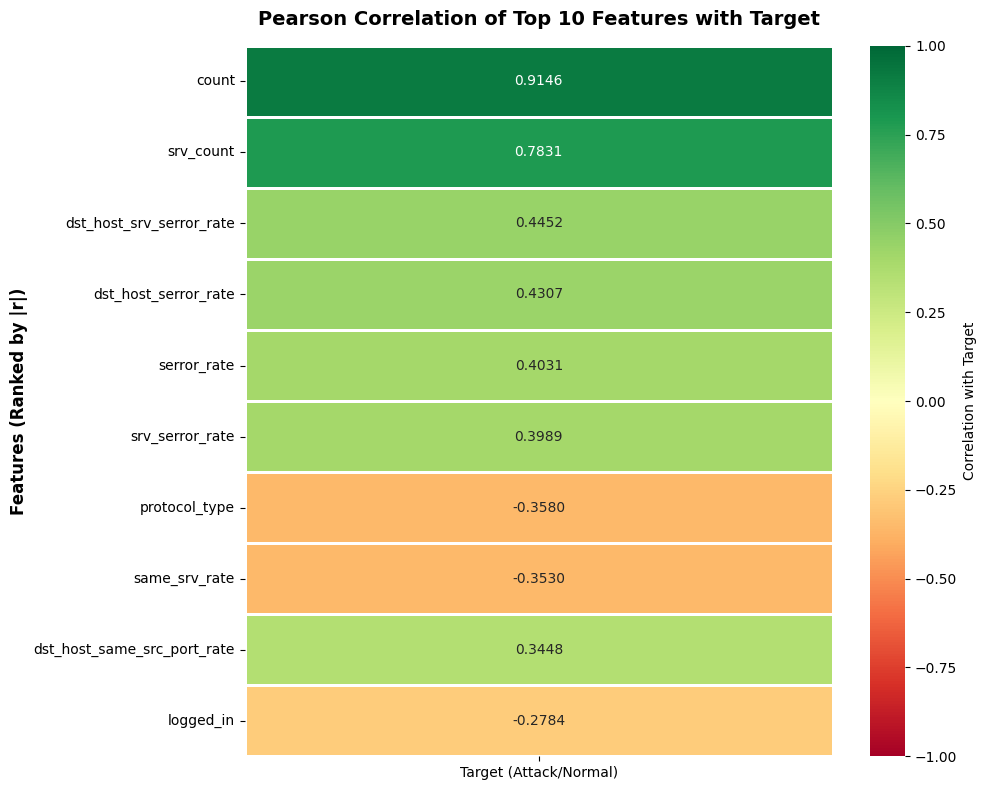


SUMMARY
Total features in dataset: 41
Selected top features: 10

Ranked feature vector (most to least relevant):
rank_features = ['count', 'srv_count', 'dst_host_srv_serror_rate', 'dst_host_serror_rate', 'serror_rate', 'srv_serror_rate', 'protocol_type', 'same_srv_rate', 'dst_host_same_src_port_rate', 'logged_in']

FEATURE STATISTICS
Rank   Feature                   Correlation  |Correlation|  
--------------------------------------------------------------------------------
1      count                     0.9146       0.9146         
2      srv_count                 0.7831       0.7831         
3      dst_host_srv_serror_rate  0.4452       0.4452         
4      dst_host_serror_rate      0.4307       0.4307         
5      serror_rate               0.4031       0.4031         
6      srv_serror_rate           0.3989       0.3989         
7      protocol_type             -0.3580      0.3580         
8      same_srv_rate             -0.3530      0.3530         
9      dst_host_same_src

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import LabelEncoder

# Load dataset
kdd = fetch_kddcup99(subset='SA', as_frame=True)
X = kdd.data
y = kdd.target

# Convert binary labels
y_binary = y.apply(lambda x: 0 if x == b'normal.' else 1)

# ============================================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================================

# Identify categorical columns
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols[:5]}...")

# Encode categorical variables
X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])

# ============================================================================
# PEARSON CORRELATION ANALYSIS
# ============================================================================

# Combine features with target
df_analysis = pd.concat([X_encoded, y_binary.rename('target')], axis=1)

# Calculate Pearson correlation with target
correlations = df_analysis.corr()['target'].drop('target')

# Get absolute values and sort
correlations_abs = correlations.abs().sort_values(ascending=False)

print("\n" + "="*80)
print("PEARSON CORRELATION RANKING (Top 20)")
print("="*80)
for i, (feature, corr) in enumerate(correlations_abs.head(20).items(), 1):
    print(f"{i:2d}. {feature:25s}: {correlations[feature]:7.4f} (|r| = {corr:.4f})")

# ============================================================================
# SELECT TOP 10 FEATURES
# ============================================================================

top_10_features = correlations_abs.head(10).index.tolist()
rank_features = top_10_features.copy()  # Ranked from most to least relevant

print("\n" + "="*80)
print("TOP 10 MOST RELEVANT FEATURES")
print("="*80)
for i, feature in enumerate(rank_features, 1):
    print(f"{i:2d}. {feature:25s}: r = {correlations[feature]:7.4f}, |r| = {correlations_abs[feature]:.4f}")

# ============================================================================
# CREATE CORRELATION MATRIX FOR TOP 10 FEATURES
# ============================================================================

# Include target in correlation matrix
features_with_target = rank_features + ['target']
correlation_matrix_top10 = df_analysis[features_with_target].corr()

# ============================================================================
# PLOT 1: CORRELATION MATRIX HEATMAP
# ============================================================================

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_top10, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=1,
            cbar_kws={'label': 'Pearson Correlation Coefficient'},
            vmin=-1, 
            vmax=1)
plt.title('Correlation Matrix - Top 10 Features + Target\n(KDD Cup 99 Dataset)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix_top10.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 2: BAR CHART OF CORRELATIONS WITH TARGET
# ============================================================================

plt.figure(figsize=(12, 6))
colors = ['#d62728' if correlations[f] < 0 else '#2ca02c' for f in rank_features]
bars = plt.barh(range(len(rank_features)), 
                [correlations[f] for f in rank_features],
                color=colors,
                edgecolor='black',
                linewidth=1.5)

plt.yticks(range(len(rank_features)), 
           [f"{i+1}. {f}" for i, f in enumerate(rank_features)])
plt.xlabel('Pearson Correlation Coefficient', fontsize=12, fontweight='bold')
plt.ylabel('Features (Ranked)', fontsize=12, fontweight='bold')
plt.title('Top 10 Features by Absolute Pearson Correlation with Target\n(Green: Positive, Red: Negative)', 
          fontsize=14, fontweight='bold', pad=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, feature) in enumerate(zip(bars, rank_features)):
    width = bar.get_width()
    plt.text(width + (0.01 if width > 0 else -0.01), 
             bar.get_y() + bar.get_height()/2,
             f'{correlations[feature]:.4f}',
             ha='left' if width > 0 else 'right',
             va='center',
             fontsize=9,
             fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_ranking_top10.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 3: CORRELATION WITH TARGET ONLY (CLEANER VIEW)
# ============================================================================

plt.figure(figsize=(10, 8))
target_corr_top10 = correlations[rank_features]
sns.heatmap(target_corr_top10.to_frame(), 
            annot=True, 
            fmt='.4f', 
            cmap='RdYlGn', 
            center=0,
            linewidths=2,
            cbar_kws={'label': 'Correlation with Target'},
            vmin=-1, 
            vmax=1)
plt.title('Pearson Correlation of Top 10 Features with Target', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('Features (Ranked by |r|)', fontsize=12, fontweight='bold')
plt.xticks([0.5], ['Target (Attack/Normal)'], rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_with_target_top10.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# SUMMARY OUTPUT
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Total features in dataset: {X.shape[1]}")
print(f"Selected top features: {len(rank_features)}")
print(f"\nRanked feature vector (most to least relevant):")
print(f"rank_features = {rank_features}")

print("\n" + "="*80)
print("FEATURE STATISTICS")
print("="*80)
print(f"{'Rank':<6} {'Feature':<25} {'Correlation':<12} {'|Correlation|':<15}")
print("-"*80)
for i, feature in enumerate(rank_features, 1):
    print(f"{i:<6} {feature:<25} {correlations[feature]:<12.4f} {correlations_abs[feature]:<15.4f}")

# ============================================================================
# CREATE REDUCED DATASET WITH TOP 10 FEATURES
# ============================================================================

X_top10 = X_encoded[rank_features]
print("\n" + "="*80)
print(f"Reduced dataset shape: {X_top10.shape}")
print(f"Original dataset shape: {X_encoded.shape}")
print(f"Dimensionality reduction: {X.shape[1]} → {len(rank_features)} features")

# Save ranked features to file
with open('ranked_features_top10.txt', 'w') as f:
    f.write("Top 10 Features Ranked by Pearson Correlation (Most to Least Relevant)\n")
    f.write("="*80 + "\n\n")
    for i, feature in enumerate(rank_features, 1):
        f.write(f"{i}. {feature}: r = {correlations[feature]:.4f}, |r| = {correlations_abs[feature]:.4f}\n")
    f.write("\n" + "="*80 + "\n")
    f.write(f"rank_features = {rank_features}\n")

print("\nRanked features saved to 'ranked_features_top10.txt'")
print("Correlation plots saved as PNG files")

In [7]:
import pandas as pd

def create_balanced_sample(df, target_column='class', num_samples=1000):
    # Ensure that num_samples is even to allow 50/50 split
    if num_samples % 2 != 0:
        raise ValueError("Number of samples must be even to ensure 50% distribution of labels.")

    # Split the data into two groups: one for each class
    class_0 = df[df[target_column] == 0]
    class_1 = df[df[target_column] == 1]
    
    # Find the minimum number of samples between the two classes to avoid imbalance issues
    min_class_size = min(len(class_0), len(class_1))
    
    if min_class_size * 2 < num_samples:
        raise ValueError(f"Not enough data to create a balanced dataset of {num_samples} samples.")

    # Sample from each class to ensure 50/50 split
    half_samples = num_samples // 2
    class_0_sample = class_0.sample(n=half_samples)
    class_1_sample = class_1.sample(n=half_samples)
    
    # Concatenate the two samples to form the balanced dataset
    df_n = pd.concat([class_0_sample, class_1_sample]).sample(frac=1).reset_index(drop=True)  # Shuffle and reset index
    
    return df_n

# Usage
df = df.drop(columns=["e_magic", "e_crlc"])
y = df[target]
X = df.drop(columns=[target])

# Create balanced sample
df_n = create_balanced_sample(df)
print(df_n.shape)

(1000, 54)


In [23]:
print(X.isna().sum())
df_cleaned = X.dropna(axis=1)
print(X.isna().sum())

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [31]:
df_new = pd.concat([X,y_binary],axis=1)
correlation_matrix = df.corr()

In [32]:
# df = X,y


ValueError: could not convert string to float: b'tcp'

In [11]:
print("X shape = ", X.shape)
print("Y shape = ", y.shape)
y.value_counts()

X shape =  (5184, 53)
Y shape =  (5184,)


class
1    2683
0    2501
Name: count, dtype: int64

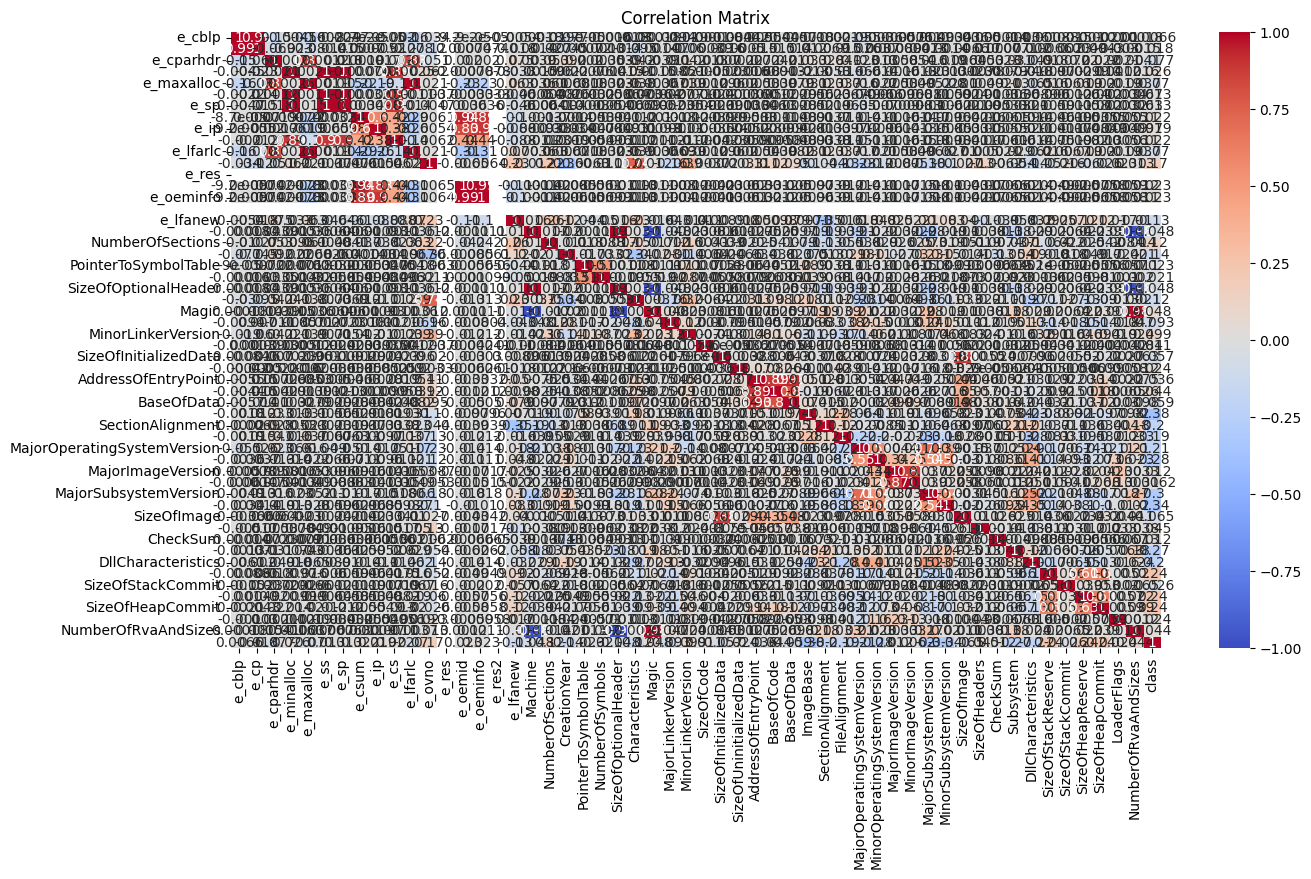

In [12]:
# Plot the correlation matrix using seaborn
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [13]:
class_correlations = correlation_matrix[target].sort_values(ascending=False)
all_list_atributs = correlation_matrix[target].sort_values(ascending=False).index.tolist()
list_atributs = all_list_atributs[1:]

# Display the sorted correlations
print(class_correlations)
print(list_atributs)

class                          1.000000
SizeOfStackReserve             0.243861
SizeOfHeapCommit               0.235746
SizeOfHeapReserve              0.235153
e_ovno                         0.170040
NumberOfSections               0.124798
MinorLinkerVersion             0.099256
Magic                          0.047762
SizeOfHeaders                  0.044557
NumberOfRvaAndSizes            0.044198
BaseOfCode                     0.043556
e_minalloc                     0.025531
SizeOfUninitializedData        0.024442
LoaderFlags                    0.023528
e_oemid                        0.023233
e_oeminfo                      0.023043
e_cs                           0.022322
e_csum                         0.021903
e_ip                           0.019424
e_ss                           0.013411
e_sp                           0.012614
CheckSum                       0.012330
MajorImageVersion              0.012285
SizeOfCode                     0.011383
e_cblp                         0.006623


## Metrics of Evaluation

We should ahve metrics of evaluation to the Quantum Machine Learning and also the Quantum Hardware with the [backend atributs](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.IBMBackend). So with this atribust we will be able to characterize the quantum computers.

In [5]:
def get_confusion_matrix_elements(test_labels, predictions):
    TP = np.sum((test_labels == 1) & (predictions == 1))
    TN = np.sum((test_labels == 0) & (predictions == 0))
    FP = np.sum((test_labels == 0) & (predictions == 1))
    FN = np.sum((test_labels == 1) & (predictions == 0))
    return TP, TN, FP, FN

def mean_qubits(backend, property):
  mean = 0
  for i in range(0,backend.num_qubits):
    if(property == 'readout_error'):
      mean += backend.properties().readout_error(i)
    elif(property=='t1'):
      mean += backend.properties().t2(0)
    elif(property=='t2'):
      mean += backend.properties().t2(0)
  mean=mean/backend.num_qubits
  return mean

def json_qiskit(name):
  TOKEN = "482cfbd6dec57e562dd79640807643b60b7388db6a0ff63e30b4bd92d4d55601a902c6f005413b8a69f6677daf23c82fa14626594ab3656d9c8c0e9229f920de"

  response = requests.request(
    "GET",
    "https://api.quantum-computing.ibm.com/runtime/workloads/me",
    headers={
        "Accept": "application/json",
        "Authorization": "Bearer "+TOKEN
    },
    )
  # Parse the JSON response
  usage_seconds = 0
  estimated_running_time_seconds = 0
  data = response.json()
  # Iterate over the 'workloads' list to find the latest backend with the name
  for workload in data['workloads']:
    if workload['backend'] == name:
          usage_seconds = workload.get('usage_seconds', None)
          estimated_running_time_seconds = workload.get('estimated_running_time_seconds', None)
          break
    else:
        #print(f"Backend {name} not found in the workloads.")
        continue
  return usage_seconds, estimated_running_time_seconds

def calculate_h_m_s_ms(end, start):
  # Calculate elapsed time in seconds
  elapsed_time_seconds = end - start
  # Convert elapsed time into hours, minutes, seconds
  hours = int(elapsed_time_seconds // 3600)
  minutes = int((elapsed_time_seconds % 3600) // 60)
  seconds = int(elapsed_time_seconds % 60)
  milliseconds = int((elapsed_time_seconds - int(elapsed_time_seconds)) * 1000)
  return elapsed_time_seconds#[hours, minutes, seconds, milliseconds]

# Define evaluation metric functions
def calculate_metrics(test_labels, predictions):
    TP, TN, FP, FN = get_confusion_matrix_elements(test_labels, predictions)
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0 #recall=sensitivity
    sensitivity = recall
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    # calculate sensitivity and specificity
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return TP, TN, FP, FN, accuracy, precision, sensitivity, specificity, f1_score

def calculate_metrics_hardware(backend):
  #Read the json according to the backend you are using and get the: 'usage_seconds', 'estimated_running_time_seconds'
  usage_seconds, estimated_running_time_seconds = json_qiskit(backend.name)
  mean_readout_error = mean_qubits(backend,'readout_error')
  mean_t1 = mean_qubits(backend,'t1')
  mean_t2 = mean_qubits(backend,'t1')

  return usage_seconds, estimated_running_time_seconds,mean_readout_error, mean_t1, mean_t2


In [6]:
import pandas as pd

# Create an empty DataFrame with specified columns
df_results = pd.DataFrame({
    'Model': [],
    'TP': [],
    'TN': [],
    'FP': [],
    'FN': [],
    'Accuracy': [],
    'Precision': [],
    'Sensitivity': [],
    'Specificity': [],
    'F1 Score': [],
    'Elapsed Time (s)':[],
    'Usage (s)':[],
    'Estimated Usage (s)': [],
    'Num Qubits': [],
    'Median T1':[],
    'Median T2':[],
    'Median Read Out Error':[]
})
df_results

,Model,TP,TN,FP,FN,Accuracy,Precision,Sensitivity,Specificity,F1 Score,Elapsed Time (s),Usage (s),Estimated Usage (s),Num Qubits,Median T1,Median T2,Median Read Out Error


In [7]:
def inicial_df():
  df_results = pd.DataFrame({
    'Hardware': [],
    'Dimension': [],
    'TP': [],
    'TN': [],
    'FP': [],
    'FN': [],
    'Accuracy': [],
    'Precision': [],
    'Sensitivity': [],
    'Specificity': [],
    'F1 Score': [],
    'Elapsed Time (s)':[],
    'Usage (s)':[],
    'Estimated Usage (s)': [],
    'Num Qubits': [],
    'Median T1':[],
    'Median T2':[],
    'Median Read Out Error':[]
  })
  return df_results

def metrics_of_evaluation(name, dimension, qsvc,end,start,test_features, test_labels, backend):
  usage_seconds, estimated_running_time_seconds,mean_readout_error, mean_t1, mean_t2 = calculate_metrics_hardware(backend)
  enlapse_time = end-start
  predictions = qsvc.predict(test_features)
  TP, TN, FP, FN, accuracy, precision, sensitivity, specificity, f1_score = calculate_metrics(test_labels, predictions)

  # Create a DataFrame to store the results
  df_results = pd.DataFrame({
      'Hardware':name,
      'Dimension':dimension,
      'TP': [TP],
      'TN': [TN],
      'FP': [FP],
      'FN': [FN],
      'Accuracy': [accuracy],
      'Precision': [precision],
      'Sensitivity': [sensitivity],
      'Specificity': [specificity],
      'F1 Score': [f1_score],
      'Elapsed Time (s)': [enlapse_time],
      'Usage (s)':[usage_seconds],
      'Estimated Usage (s)': [estimated_running_time_seconds],
      'Num Qubits': [backend.num_qubits],
      'Median T1':[mean_t1],
      'Median T2':[mean_t2],
      'Median Read Out Error':[mean_readout_error]

  })
  return df_results

def metrics_of_evaluation_classicaly(svc,dimension,end,start,test_features, test_labels):
  predictions = svc.predict(test_features)
  TP, TN, FP, FN, accuracy, precision, sensitivity, specificity, f1_score = calculate_metrics(test_labels, predictions)
  usage_time = end-start
  # Create a DataFrame to store the results
  df_results = pd.DataFrame({
      'Dimension':dimension,
      'TP': [TP],
      'TN': [TN],
      'FP': [FP],
      'FN': [FN],
      'Accuracy': [accuracy],
      'Precision': [precision],
      'Sensitivity': [sensitivity],
      'Specificity': [specificity],
      'F1 Score': [f1_score],
      'Elapsed Time (s)': [usage_time],
      'Usage (s)':[usage_time],


  })
  return df_results

def should_skip_execution(results_file, samples, start_at):
    if os.path.exists(results_file):
        df_existing = pd.read_csv(results_file)
        # If there are existing records with the same sample count and dimensions greater than or equal to start_at, return True
        if ((df_existing["Samples"] == samples) & (df_existing["Dimension"] >= start_at)).any():
            return True
    
    return False

# Feature Extractions

### Classical PCA Model

In [37]:
# Now adapt 3 functions: classical_pca, qpca_precomputed_qkernel and qpca_rbf_qkernel that the quantum operations are using just a simulator and we are sending X_train[rank_features[:n]] where n is from 2 to 10
# also we do 10 fold cross validation in the logistic regression model

In [39]:
class KDD:
    def __init__(self, test_size=0.2, random_state=42):
        # Load KDDCup99 dataset
        data = fetch_kddcup99(as_frame=True, percent10=True)
        df = data.frame

        target_col = df.columns[-1]  # Get the last column name
        
        # Separate features and target
        self.X = df.drop(columns=[target_col])
        # self.y = df[target_col]
        # print(self.y[:10])
        # # Encode categorical features
        # for col in self.X.select_dtypes(include=["object"]).columns:
        #     self.X[col] = LabelEncoder().fit_transform(self.X[col])
        
        # # Encode labels (handle bytes if necessary)
        # if self.y.dtype == 'object' or isinstance(self.y.iloc[0], bytes):
        #     # Convert bytes to string if needed
        #     self.y = self.y.apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
        # self.y = LabelEncoder().fit_transform(self.y)
        y_raw = df[target_col]
        if y_raw.dtype == 'object' or isinstance(y_raw.iloc[0], bytes):
            y_raw = y_raw.apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
        
        # Convert: normal. = 0, everything else = 1
        self.y = (y_raw != 'normal.').astype(int)
        
        # Encode categorical features
        for col in self.X.select_dtypes(include=["object"]).columns:
            self.X[col] = LabelEncoder().fit_transform(self.X[col])
        
        # Train-test split
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=test_size,
            random_state=random_state,
            stratify=self.y
        )
        
        # Compute Pearson ranking once
        self.rank_features = self._pearson_rank_features()
    
    def _pearson_rank_features(self):
        """
        Rank features using absolute Pearson correlation with the target.
        Returns a list of feature names ordered from highest to lowest correlation.
        """
        df_corr = pd.concat(
            [self.X_train, pd.Series(self.y_train, name="target", index=self.X_train.index)],
            axis=1
        )
        correlations = df_corr.corr()["target"].drop("target").abs()
        ranked_features = correlations.sort_values(ascending=False).index.tolist()
        return ranked_features
    
    def dataset(self, dimensions, samples=100000):
        """
        Return train/test sets using top-N Pearson-ranked features,
        balanced with 50% class 0 and 50% class 1.
        """
        selected_features = self.rank_features[:dimensions]

        # Number of samples per class
        samples_per_class = samples // 2
        unique, counts = np.unique(self.y, return_counts=True)

        # print("Class distribution:")
        # for cls, cnt in zip(unique, counts):
        #     print(f"Class {cls}: {cnt} samples")

        # Indices for each class
        idx_class_0 = np.where(self.y == 0)[0]
        idx_class_1 = np.where(self.y == 1)[0]
        print("Total samples for class (0/normal, 1/abnormal):",idx_class_0.shape," , ",idx_class_1.shape)

        # Reproducible random sampling
        rng = np.random.default_rng(seed=42)
        idx_0_sampled = rng.choice(idx_class_0, size=samples_per_class, replace=False)
        idx_1_sampled = rng.choice(idx_class_1, size=samples_per_class, replace=False)
        
        print(idx_0_sampled.shape)
        print(idx_1_sampled.shape)

        # Combine and shuffle
        sampled_indices = np.concatenate([idx_0_sampled, idx_1_sampled])
        rng.shuffle(sampled_indices)

        # Subset X and y
        X_sampled = self.X.iloc[sampled_indices][selected_features]
        y_sampled = self.y[sampled_indices]

        # Train-test split (no stratification needed — already balanced)
        X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
            X_sampled,
            y_sampled,
            test_size=0.2,
            random_state=42
        )

        return X_train_sel, X_test_sel, y_train_sel, y_test_sel

In [56]:
def classical_pca(X_train, y_train, X_test, y_test, dimension):
    kernelpca_rbf = KernelPCA(n_components=dimension, kernel='rbf') #we changed 2 to dimentions
    kernelpca_rbf.fit(X_train)
    train_features_rbf = kernelpca_rbf.transform(X_train)
    test_features_rbf = kernelpca_rbf.transform(X_test)
    LR = LogisticRegression() #other models
    LR.fit(train_features_rbf, y_train)
    return LR, train_features_rbf, test_features_rbf
    
def main_cpca_correlation(samples=500, start_at=2, end_at=10, results_file = "results/cpca.csv"):
    kdd_data = KDD()
    file_exists = os.path.exists(results_file)
    for dimension in range(start_at, end_at):
        if not should_skip_execution(results_file, samples, dimension):
            # Pass samples parameter to dataset method
            X_train, X_test, y_train, y_test = kdd_data.dataset(
                dimensions=dimension,
                samples=samples
            )
            
            print(f"Dimension {dimension}, Total Samples: {samples}")
            print("Shape: ", X_train.shape, X_test.shape, y_train.shape, y_test.shape)
            
            start = time.time()
            model, X_train_transformed, X_test_transformed = classical_pca(
                X_train, y_train, X_test, y_test, dimension)
            
            df_model = metrics_of_evaluation_classicaly(
                model, dimension, time.time(), start, X_train_transformed, y_train
            )
            df_model["Samples"] = samples
            
            file_exists = os.path.exists(results_file)
            df_model.to_csv(results_file, mode='a', index=False, header=not file_exists)
    
    return True

### Classical PCA precomputed + Quantum Kernel

In [63]:
def qpca_precomputed_qkernel(X_train, y_train, X_test, y_test, dimension):
    # # Hrdware setup
    # backend = service.backend(name)
    # sampler = Sampler(backend)
    
    feature_map = ZZFeatureMap(feature_dimension=dimension, reps=2)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

    # Compute kernel matrix
    kernel_matrix_train = quantum_kernel.evaluate(x_vec=X_train)
    kernel_matrix_test = quantum_kernel.evaluate(x_vec=X_test)

    # # Perform clustering
    # clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', assign_labels='kmeans')
    # predicted_labels = clustering.fit_predict(kernel_matrix)

    # return predicted_labels, backend
    kernelpca_q = KernelPCA(n_components=dimension, kernel='precomputed')
    train_features_q = kernelpca_q.fit_transform(kernel_matrix_train)
    test_features_q = kernelpca_q.fit_transform(kernel_matrix_test) 
    LR = LogisticRegression()
    LR.fit(train_features_q, y_train)
    return LR, train_features_q, test_features_q

def main_qpca_q_correlation(samples=500, start_at=0, end_at=20, results_file="results/qpca_qkernel.csv"):
    kdd_data = KDD()
    # **Check if the CSV already exists**
    file_exists = os.path.exists(results_file)

    for dimension in range(start_at, end_at):
        if should_skip_execution(results_file, samples, dimension) == False:
            X_train, X_test, y_train, y_test = kdd_data.dataset(dimension, samples)
            print("Shape: ", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

            start = time.time()
            model, X_train, X_test = qpca_precomputed_qkernel(X_train, y_train, X_test, y_test, dimension)

            # df_model = metrics_of_evaluation(dimension, model, time.time(), start, X_train, y_train)
            df_model = metrics_of_evaluation_classicaly(
                model, dimension, time.time(), start, X_train, y_train
            )
            df_model["Samples"] = samples  # Add sample size info
            # **Append new results while keeping existing content**
            df_model.to_csv(results_file, mode='a', index=False, header=not file_exists)

            # **Ensure the header is written only once**
            file_exists = True  

    return True

### Classical PCA rbf + Quantum Kernel

In [66]:
def qpca_rbf_qkernel(X_train, y_train, X_test, y_test, dimension):
    # sampler = Sampler(backend)
    
    feature_map = ZZFeatureMap(feature_dimension=dimension, reps=2)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

    # Compute kernel matrix
    kernel_matrix_train = quantum_kernel.evaluate(x_vec=X_train)
    kernel_matrix_test = quantum_kernel.evaluate(x_vec=X_test)

    kernelpca_q = KernelPCA(n_components=dimension, kernel='rbf')
    train_features_q = kernelpca_q.fit_transform(kernel_matrix_train)
    test_features_q = kernelpca_q.fit_transform(kernel_matrix_test) 
    LR = LogisticRegression()
    LR.fit(train_features_q, y_train)
    return LR, train_features_q, test_features_q

def main_qpca_rbf_correlation(computers='all', dataset=0, samples=500, start_at=0, end_at=20, results_file="results/qpca_qData.csv"):    
    kdd_data = KDD()
    # **Check if the CSV already exists**
    file_exists = os.path.exists(results_file)

    for dimension in range(start_at, end_at):
        if should_skip_execution(results_file, samples, dimension) == False:
            X_train, X_test, y_train, y_test = kdd_data.dataset(dimension, samples)
            print("Shape: ", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

            start = time.time()
            model, X_train, X_test = qpca_rbf_qkernel(X_train, y_train, X_test, y_test, dimension)

            # df_model = metrics_of_evaluation(dimension, model, time.time(), start, X_train, y_train)
            df_model = metrics_of_evaluation_classicaly(
                model, dimension, time.time(), start, X_train, y_train
            )
            df_model["Samples"] = samples  # Add sample size info
            # **Append new results while keeping existing content**
            df_model.to_csv(results_file, mode='a', index=False, header=not file_exists)

            # **Ensure the header is written only once**
            file_exists = True  

    return True

# Model Training

In [12]:
kdd_data = KDD()

TOTAL_SAMPLES = kdd_data.X.shape[0]

samples = int((TOTAL_SAMPLES * 1) / 10)   

print("TOTAL_SAMPLES:", TOTAL_SAMPLES)
print("Samples:", samples)


TOTAL_SAMPLES: 494021
Samples: 49402


### Classical PCA

In [ ]:
for j in range(1, 11): # Size of dataset: 10%, 20%, ..., 100%
    samples = int((TOTAL_SAMPLES * j) / 10)   
    df_result_pca = main_cpca_correlation(samples = samples, start_at=2, end_at=11)
print("**********************************************")

### Classical PCA precomputed + Quantum Kernel

In [ ]:
for j in range(1, 11): # Size of dataset: 10%, 20%, ..., 100%
    samples = int((TOTAL_SAMPLES * j) / 100)  
    df_result_qpca = main_qpca_q_correlation(samples = samples, start_at=2, end_at=20) #"ibm_brisbane", start_at=2, end_at=20)
print("**********************************************")

### Classical PCA rbf + Quantum Kernel

In [ ]:
for j in range(1, 11): # Size of dataset: 10%, 20%, ..., 100%
    samples = int((TOTAL_SAMPLES * j) / 100)   
    df_result_qkernel0 = main_qpca_rbf_correlation(samples = samples, start_at=2, end_at=11)
print("**********************************************")

You Need to change the model mains and also input a function to chech if the look need to be done

# Article Observations
* We are the first one to do an analogy in SCM and QML in a real quantum computer

Tougths:
* Fist is the dataset with highest corelations
* The problem is that we are doing feature selection based on the best features that are more corelated with our output. But we want to have features that are now as good to our output. Like the best corelated and the least corelated for example

Hipothesis:
- The results might be different
- Superconducting qubit with

- Get the time for predicting the test data

# Tutorial for ARC UTSA Supercomputer
#### Commands to enter in ARC UTSA
ssh ats852@arc.utsa.edu

srun -p compute1 -n 1 -t 48:00:00 --pty bash

module restore experiments

conda activate QUANTUM

#run the code

cd QML_in_SCM/src

python3 01_qml_in_scm.py

#### Vim Document
vim name_file.py            oppen file

a                           write file

ESC + dd                    delete the entire line

ESC + :w                    save the writing on file

ESC + :q                    close file

ESC + :wq                   save and close file

srun -p gpu2v100 -n 1 -t 24:00:00 -c 80 --pty bash

pip install qiskit-aer-gpu